# Brain-behavior association and functional decoding

This notebook relates individual RSI values to HCP behavioral phenotypes. It then visualizes a selected parcel-wise association map and decodes using Neurosynth maps.


In [ ]:
from pathlib import Path
import tempfile

import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from IPython.display import display
from nilearn.image import load_img, resample_to_img
from nilearn.surface import load_surf_data
from PIL import Image
from scipy.linalg import lstsq
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from wordcloud import WordCloud


def find_project_root(start=None):
    """Locate the RISE root from a working directory inside the project."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / 'rise').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise RuntimeError(f'Could not find the RISE project root from {start}')


project_root = find_project_root()
info_dir = project_root / 'data/HCP/info'
rsi_path = project_root / 'results/rsi/HCP/test_rsi.csv'
neurosynth_dir = project_root / 'resources/neurosynth'

font_path = project_root / 'font/Whitney-Medium.otf'
wordcloud_font_path = project_root / 'font/SF-Pro-Display-Regular.ttf'
fm.fontManager.addfont(str(font_path))
plt.rcParams['font.family'] = fm.FontProperties(fname=str(font_path)).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none'

from rise import fetch_fine_grained_surface, fetch_fine_grained_volume
from rise.vis import visualize_surface_32k_fs_LR

print('Project root:', project_root)
print('Neurosynth maps:', len(list(neurosynth_dir.glob('*.nii.gz'))))


## Load RSI and behavioral data


In [2]:
test_subject_ids = (
    pd.read_csv(info_dir / 'test.txt', header=None)[0]
    .astype(str)
    .tolist()
)

# Normalization by group mean can be omitted, as it does not affect the parcel-wise brain-behavior correlation statistics.
test_rsi = pd.read_csv(rsi_path, index_col=0)
test_rsi.index = test_rsi.index.astype(str)
test_rsi = test_rsi/test_rsi.mean()


hcp_metadata = pd.read_csv(info_dir / 'hcp_998.csv')
hcp_metadata['Subject'] = hcp_metadata['Subject'].astype(str)
hcp_metadata = hcp_metadata.set_index('Subject')

# Covariates use age in years and sex encoded as male=1, female=-1.
hcp_metadata['age'] = hcp_metadata['Age_in_Yrs']
hcp_metadata['sex'] = np.where(hcp_metadata['Gender'].eq('M'), 1, -1)

print('Test IDs:', len(test_subject_ids))
print('RSI subjects:', len(test_rsi))
print('RSI/metadata overlap:', len(test_rsi.index.intersection(hcp_metadata.index)))


Test IDs: 708
RSI subjects: 708
RSI/metadata overlap: 708


In [3]:
test_rsi

,r0,r1,r2,r3,r4,r5,r6,r7,r8,r9,...,r7330,r7331,r7332,r7333,r7334,r7335,r7336,r7337,r7338,r7339
100307,0.591502,0.606078,0.593406,0.420584,0.508348,0.666349,0.486855,0.601800,0.681357,0.556167,...,1.476886,1.244250,2.167921,1.134287,1.128764,1.342882,1.024417,1.177335,1.016385,1.804821
100408,1.889327,1.458318,1.228477,1.638623,1.291509,1.098222,1.348149,1.180069,1.639604,1.361154,...,1.205842,0.583527,1.512907,0.746653,0.624468,0.974198,0.580773,0.599804,0.704638,1.608388
101006,0.792973,0.847502,0.902233,1.035159,1.097959,1.044730,1.108306,0.955022,0.643016,1.035251,...,0.409906,0.568251,0.618702,1.008311,0.606687,0.487799,0.580262,0.682162,0.989101,0.362956
101107,1.691273,1.655217,1.811715,2.060931,1.892570,1.847768,1.958665,1.848575,1.525574,1.913802,...,1.733270,1.661327,1.227378,1.121959,1.377728,1.820968,1.249718,1.565021,1.272334,1.858827
101309,0.394571,0.720263,0.772060,0.398360,0.741940,0.767403,0.624872,0.758820,0.619356,0.763006,...,1.822159,0.935446,0.977644,0.705849,0.759902,1.392087,0.673369,0.907858,0.697658,1.568847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991267,1.084131,1.055319,1.033595,0.486335,0.830910,0.898557,0.745280,1.000348,1.245098,0.913496,...,0.592899,0.456753,0.979556,0.794206,0.491086,0.754249,0.576213,0.530660,0.739574,0.788984
992673,0.830245,0.778354,0.726432,0.742852,0.638848,0.727938,0.590445,0.695587,0.957649,0.679141,...,0.782177,0.727602,1.042230,1.231985,0.830858,0.712112,0.679276,1.025727,1.234679,0.596396
992774,1.253380,1.216975,1.187549,1.590913,1.502873,1.421751,1.561726,1.218579,1.236048,1.348332,...,1.196934,0.788095,1.242331,0.720919,0.907789,1.073180,1.061019,0.678282,0.948251,0.953266
993675,0.632392,0.850391,1.015716,0.604479,1.093796,1.179642,0.968241,1.045452,0.722646,0.999393,...,0.803858,0.940574,0.977959,0.834180,0.832068,1.065140,0.939374,0.819283,0.596705,0.739103


## Behavioral phenotype groups

In [4]:
alertness = ['MMSE_Score', 'PSQI_Score']

cognition = [
    'PicSeq_Unadj', 'CardSort_Unadj', 'Flanker_Unadj', 'PMAT24_A_CR',
    'ReadEng_Unadj', 'PicVocab_Unadj', 'ProcSpeed_Unadj', 'DDisc_AUC_40K',
    'VSPLOT_TC', 'SCPT_SEN', 'SCPT_SPEC', 'IWRD_TOT', 'ListSort_Unadj',
    'CogCrystalComp_Unadj', 'CogTotalComp_Unadj', 'CogFluidComp_Unadj',
]

emotion_recognition = ['ER40_CR', 'ER40ANG', 'ER40FEAR', 'ER40HAP', 'ER40NOE', 'ER40SAD']
negative_affect = [
    'AngAffect_Unadj', 'AngHostil_Unadj', 'AngAggr_Unadj',
    'FearAffect_Unadj', 'FearSomat_Unadj', 'Sadness_Unadj',
]
psychological_well_being = ['LifeSatisf_Unadj', 'MeanPurp_Unadj', 'PosAffect_Unadj']
social_relationships = [
    'Friendship_Unadj', 'Loneliness_Unadj', 'PercHostil_Unadj',
    'PercReject_Unadj', 'EmotSupp_Unadj', 'InstruSupp_Unadj',
]
stress_self_efficacy = ['PercStress_Unadj', 'SelfEff_Unadj']
emotion = (
    emotion_recognition + negative_affect + psychological_well_being
    + social_relationships + stress_self_efficacy
)

motor = ['Endurance_Unadj', 'GaitSpeed_Comp', 'Dexterity_Unadj', 'Strength_Unadj']
personality = ['NEOFAC_A', 'NEOFAC_O', 'NEOFAC_C', 'NEOFAC_N', 'NEOFAC_E']
sensory = ['Odor_Unadj', 'PainIntens_RawScore', 'Taste_Unadj', 'Mars_Final']
task_performance = [
    'Emotion_Task_Face_Acc', 'Language_Task_Math_Avg_Difficulty_Level',
    'Language_Task_Story_Avg_Difficulty_Level', 'Relational_Task_Acc',
    'Social_Task_Perc_Random', 'Social_Task_Perc_TOM', 'WM_Task_Acc',
]

all_behaviors = (
    personality + motor + sensory + emotion + task_performance
    + alertness + cognition
)
print('Behavioral phenotypes:', len(all_behaviors))


Behavioral phenotypes: 61


## Regress covariates and align subjects

Age and sex are regressed from both RSI and behavioral variables.


In [5]:
def regress_cov(features, covariance):
    """Regress covariates and restore each feature's original value range."""
    features = np.asarray(features)
    covariance = np.asarray(covariance)
    if features.ndim == 1:
        features = features[:, None]
    if covariance.ndim == 1:
        covariance = covariance[:, None]

    residuals = np.zeros_like(features, dtype=float)
    result = np.zeros_like(features, dtype=float)
    design = np.hstack([covariance, np.ones((len(covariance), 1))])

    for feature_index in range(features.shape[1]):
        coefficients = lstsq(design, features[:, feature_index])[0]
        residuals[:, feature_index] = (
            features[:, feature_index]
            - covariance.dot(coefficients[:-1])
        )

    for feature_index in range(features.shape[1]):
        feature = features[:, feature_index]
        if np.min(feature) == np.max(feature):
            result[:, feature_index] = feature
        else:
            result[:, feature_index] = MinMaxScaler(
                feature_range=(np.min(feature), np.max(feature))
            ).fit_transform(residuals[:, feature_index, None]).ravel()
    return result


def clean_behavior_data(data, threshold=0.1):
    """Mean-impute sparse missing values and remove highly incomplete columns."""
    data = data.copy()
    missing_ratio = data.isna().mean()
    dropped = missing_ratio[missing_ratio > threshold].index.tolist()
    if dropped:
        print('Dropped phenotypes with >%.0f%% missing values: %s' %
              (threshold * 100, ', '.join(dropped)))
        data = data.drop(columns=dropped)
    return data.fillna(data.mean())


def regress_dataframe(data, confounds, postfix='_reg'):
    """Align a table with confounds and return covariate-adjusted values."""
    subjects = sorted(data.index.intersection(confounds.index))
    if not subjects:
        raise ValueError('No overlapping subjects between data and confounds')
    adjusted = regress_cov(data.loc[subjects].values, confounds.loc[subjects].values)
    return pd.DataFrame(
        adjusted,
        index=subjects,
        columns=[column + postfix for column in data.columns],
    )


def prepare_data_for_regression(
    brain_data,
    metadata,
    subject_ids,
    behavior_columns,
    confound_columns=('age', 'sex'),
):
    """Return standardized brain and behavior data in identical subject order."""
    eligible = sorted(metadata.index.intersection(pd.Index(subject_ids)))
    behavior = clean_behavior_data(metadata.loc[eligible, behavior_columns])
    confounds = metadata.loc[eligible, list(confound_columns)]

    brain_adjusted = regress_dataframe(brain_data, confounds)
    behavior_adjusted = regress_dataframe(behavior, confounds, postfix='')
    subjects = sorted(brain_adjusted.index.intersection(behavior_adjusted.index))

    brain_std = StandardScaler().fit_transform(brain_adjusted.loc[subjects])
    behavior_std = StandardScaler().fit_transform(behavior_adjusted.loc[subjects])
    print('Subjects used:', len(subjects))
    return brain_std, behavior_std, subjects, behavior.columns.tolist()


## Compute parcel-wise brain-behavior correlations

In [6]:
brain_std, behavior_std, subjects_used, retained_behaviors = prepare_data_for_regression(
    test_rsi,
    hcp_metadata,
    test_subject_ids,
    behavior_columns=all_behaviors,
    confound_columns=('age', 'sex'),
)

behavior_related_map = np.corrcoef(
    behavior_std.T,
    brain_std.T,
)[:len(retained_behaviors), len(retained_behaviors):]
behavior_related_map = np.nan_to_num(behavior_related_map, nan=0.0)

print('Association matrix shape:', behavior_related_map.shape)


Subjects used: 708
Association matrix shape: (61, 7340)


## Visualize a selected association map

In [7]:
lh_label_path, rh_label_path = fetch_fine_grained_surface(
    space='fs_LR', density='32k'
)
lh_lr32k_lab = load_surf_data(lh_label_path)
rh_lr32k_lab = load_surf_data(rh_label_path)


def reallocate_to_vertex(lh_labels, rh_labels, parcel_data):
    """Map 1-based fine-grained parcel values to left/right surface vertices."""
    left_vertex = np.full((len(lh_labels), 1), np.nan)
    right_vertex = np.full((len(rh_labels), 1), np.nan)

    for index, value in enumerate(np.asarray(parcel_data)):
        parcel_label = index + 1
        if np.any(lh_labels == parcel_label):
            left_vertex[lh_labels == parcel_label, 0] = value
        elif np.any(rh_labels == parcel_label):
            right_vertex[rh_labels == parcel_label, 0] = value
    return left_vertex, right_vertex


def visualize_parcel_surface_map(parcel_data, title, cmap='YlGnBu', max_value=None):
    """Render a parcel map and return the display image without saving it."""
    if max_value is None:
        max_value = np.max(np.abs(parcel_data))
    left_vertex, right_vertex = reallocate_to_vertex(
        lh_lr32k_lab, rh_lr32k_lab, parcel_data
    )

    # The project renderer requires a path, so use an auto-deleted temporary directory.
    with tempfile.TemporaryDirectory(prefix='rise_surface_') as temp_dir:
        rendered = visualize_surface_32k_fs_LR(
            save_path=temp_dir,
            name=title,
            dpi=200,
            mymap=cmap,
            dataL=left_vertex[:, 0],
            dataR=right_vertex[:, 0],
            vmax=max_value,
            threshold=0,
            darkness=0.6,
            boundary=False,
            Sym=True,
        )
        display_width = 1000
        display_height = round(rendered.height * display_width / rendered.width)
        return rendered.resize(
            (display_width, display_height),
            Image.Resampling.LANCZOS,
        )


def set_cmap_saturation(cmap_name, saturation_factor):
    """Return a copy of a matplotlib colormap with adjusted saturation."""
    cmap = plt.get_cmap(cmap_name) if isinstance(cmap_name, str) else cmap_name
    rgba = cmap(np.linspace(0, 1, 256))
    hsv = mcolors.rgb_to_hsv(rgba[:, :3])
    hsv[:, 1] = np.clip(hsv[:, 1] * saturation_factor, 0, 1)
    rgba[:, :3] = mcolors.hsv_to_rgb(hsv)
    return mcolors.ListedColormap(rgba, name=f'{cmap.name}_sat_{saturation_factor}')


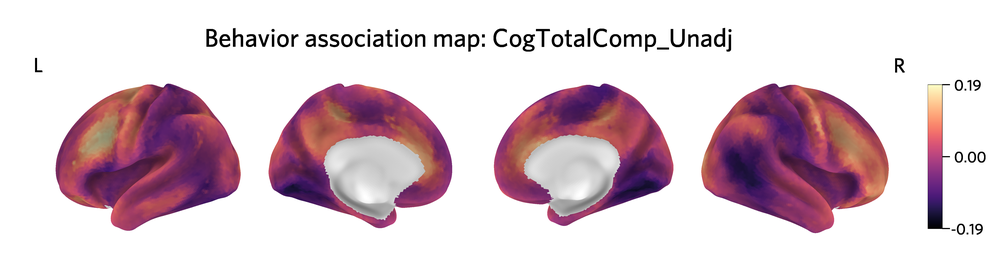

<Figure size 640x480 with 0 Axes>

In [8]:
selected_behavior = 'CogTotalComp_Unadj'
selected_map = behavior_related_map[retained_behaviors.index(selected_behavior)]
surface_cmap = set_cmap_saturation('magma', 0.9)

surface_image = visualize_parcel_surface_map(
    selected_map,
    cmap=surface_cmap,
    title=f'Behavior association map: {selected_behavior}',
)
display(surface_image)


## Decode the core associated parcels


In [9]:
top_percent = 1
absolute_map = np.abs(selected_map)
threshold = np.percentile(absolute_map, 100 - top_percent)
final_mask = (absolute_map >= threshold).astype(np.uint8)


In [10]:
def map_1d_to_3d(values_1d, atlas_data):
    """Map a parcel-level binary vector to the labeled atlas volume."""
    values_1d = np.asarray(values_1d)
    volume = np.zeros_like(atlas_data, dtype=np.uint8)
    for index, value in enumerate(values_1d):
        if value != 0:
            volume[atlas_data == (index + 1)] = 1
    return volume


def compute_functional_decoding(
    mask_1d,
    atlas_img,
    neurosynth_path,
    z_threshold=3.1,
):
    """Compare a parcel ROI with project-local Neurosynth term maps."""
    atlas_data = atlas_img.get_fdata().astype(int)
    roi_volume = map_1d_to_3d(mask_1d, atlas_data)
    roi_img = nib.Nifti1Image(roi_volume, atlas_img.affine)
    results = []

    term_paths = sorted(Path(neurosynth_path).glob('*.nii.gz'))
    if not term_paths:
        raise FileNotFoundError(f'No Neurosynth maps found in {neurosynth_path}')

    for path in term_paths:
        term = path.name.split('_association-test', 1)[0]
        term_img = load_img(path)
        term_data = np.asarray(term_img.dataobj)

        same_space = (
            roi_img.shape[:3] == term_img.shape[:3]
            and np.allclose(roi_img.affine, term_img.affine)
        )
        if same_space:
            roi_mask = roi_volume > 0
        else:
            roi_mask = resample_to_img(
                roi_img,
                term_img,
                interpolation='nearest',
                copy_header=True,
            ).get_fdata() > 0

        term_mask = term_data > z_threshold
        intersection = np.sum(roi_mask & term_mask)
        roi_size = np.sum(roi_mask)
        term_size = np.sum(term_mask)

        overlap = intersection / roi_size if roi_size else np.nan

        results.append({'term': term, 'overlap': overlap})

    return (
        pd.DataFrame(results)
        .sort_values('overlap', ascending=False)
        .reset_index(drop=True)
    )


In [11]:
fine_grained_volume, _ = fetch_fine_grained_volume(
    space='MNI152NLin6Asym', resolution='2mm'
)
atlas_img = nib.load(fine_grained_volume)
all_decoding = compute_functional_decoding(
    mask_1d=final_mask,
    atlas_img=atlas_img,
    neurosynth_path=neurosynth_dir,
    z_threshold=0,
)

display(all_decoding['term'].head(15))


0                                   language
1                                     memory
2                                  retrieval
3                                    reading
4                             working memory
5                                   judgment
6                                   encoding
7                            task difficulty
8     mood_uniformity-test_z_FDR_0.01.nii.gz
9                     language comprehension
10                            verbal fluency
11                              interference
12                    sentence comprehension
13                                    naming
14                                navigation
Name: term, dtype: object

## Display the functional decoding word cloud

In [12]:
def plot_term_wordcloud(
    decoding_df,
    top_n=10,
    title='Functional decoding',
    colormap='#006622',
    alpha=0.9,
    figsize=(4, 2.2),
    scale=200,
    seed=42,
    font_path=wordcloud_font_path,
):
    """Display the highest-overlap Neurosynth terms as a word cloud."""
    top_terms = decoding_df.head(top_n).sort_values('overlap', ascending=False)
    frequencies = dict(zip(top_terms['term'], top_terms['overlap']))
    if not frequencies:
        raise ValueError('No decoding terms are available for plotting')

    if isinstance(colormap, str) and colormap.startswith('#'):
        cmap = mcolors.LinearSegmentedColormap.from_list(
            'custom_colormap', ['white', colormap]
        )
    else:
        original_cmap = plt.get_cmap(colormap)
        truncated_colors = original_cmap(np.linspace(0, 0.7, 256))
        cmap = mcolors.LinearSegmentedColormap.from_list(
            f'truncated_{colormap}', truncated_colors
        )

    sizes = np.asarray(list(frequencies.values()))
    size_min, size_max = sizes.min(), sizes.max()
    word_colors = {}
    for word, size in frequencies.items():
        normalized = (size - size_min) / (size_max - size_min) + 0.4 if size_max > size_min else 1.0
        word_colors[word] = mcolors.to_hex(cmap(min(1.0, normalized)))

    width = int(figsize[0] * scale)
    height = int(figsize[1] * scale)
    y_grid, x_grid = np.ogrid[:height, :width]
    center_y, center_x = height // 2, width // 2
    radius_x, radius_y = (width // 2) * 0.95, (height // 2) * 0.9
    mask = (
        (x_grid - center_x) ** 2 / radius_x ** 2
        + (y_grid - center_y) ** 2 / radius_y ** 2
        > 1
    )
    mask = 255 * mask.astype(np.uint8)

    wordcloud = WordCloud(
        width=width,
        height=height,
        background_color=None,
        mode='RGBA',
        font_path=str(font_path),
        prefer_horizontal=1,
        mask=mask,
        random_state=seed,
        max_font_size=85,
        min_font_size=10,
        margin=5,
        relative_scaling=0.5,
    ).generate_from_frequencies(frequencies)
    wordcloud.recolor(color_func=lambda word, *args, **kwargs: word_colors.get(word, 'black'))

    image = np.array(wordcloud.to_image().convert('RGBA'))
    image[..., 3] = (image[..., 3] * alpha).astype(np.uint8)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=16)
    plt.tight_layout(pad=0.5)
    plt.show()
    return fig, ax


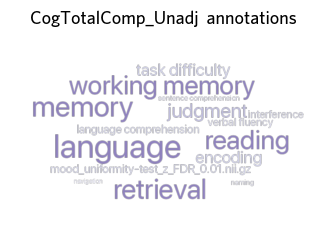

(<Figure size 400x220 with 1 Axes>,
 <Axes: title={'center': 'CogTotalComp_Unadj  annotations '}>)

In [13]:
plot_term_wordcloud(
    all_decoding,
    top_n=15,
    title= selected_behavior + '  annotations ',
    colormap='Purples',
    alpha=0.8,
    seed=10,
)
